Before we start, let's import the Python libraries.

In [ ]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

# Example

We use the banknote dataset in the file "banknotes.xlsx"

In [ ]:
# Read the data
bank_data = pd.read_excel("banknotes.xlsx")

# Set response variable as categorical.
bank_data['Status'] = pd.Categorical(bank_data['Status'])
bank_data.head()

,Status,Left,Right,Bottom,Top
0,genuine,131.0,131.1,9.0,9.7
1,genuine,129.7,129.7,8.1,9.5
2,genuine,129.7,129.7,8.7,9.6
3,genuine,129.7,129.6,7.5,10.4
4,genuine,129.6,129.7,10.4,7.7


For this problem, we will use the predictors Bottom and Top. The response is the status of the bank note which can take two labels or categories: genuine and counterfeit. We start our analysis by producing some a table and a plot to visualize the number of observations in each of these categories.  


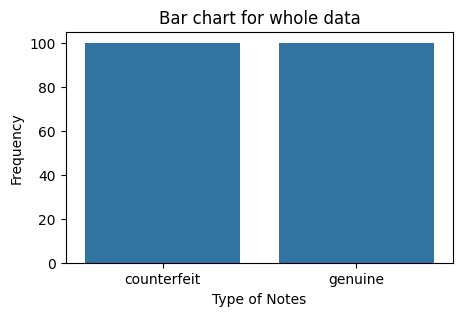

In [ ]:
# Create a bar plot to visualize the class distribution
plt.figure(figsize=(5,3))
sns.countplot(data = bank_data, x='Status')
plt.title('Bar chart for whole data')
plt.ylabel('Frequency')
plt.xlabel('Type of Notes')
plt.show()

## Training and test data

To construct and evaluate the classification methods, we split the data into two parts using `train_test_split()` from **scikit-learn**. One will serve as training data while the other as test data. We will assign 70% of the data for training. The other 30% will go to the test data. To this end, we first need to create some pandas objects.


In [ ]:
# Set full matrix of predictors.
X_full = bank_data.filter(['Top', 'Bottom'])

# Vector with responses
Y_full = bank_data.filter(['Status'])

In [ ]:
Y_full

,Status
0,genuine
1,genuine
2,genuine
3,genuine
4,genuine
...,...
195,counterfeit
196,counterfeit
197,counterfeit
198,counterfeit


Next, we set the target category in the response we use the `get_dummies()` function.

In [ ]:
# Create dummy variables.
Y_dummies = pd.get_dummies(Y_full, dtype = 'int')
Y_dummies

,Status_counterfeit,Status_genuine
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1
...,...,...
195,1,0
196,1,0
197,1,0
198,1,0


Next, we select the target variable.

In [ ]:
# Select target variable.
Y_target_full = Y_dummies['Status_counterfeit']
Y_target_full

,Status_counterfeit
0,0
1,0
2,0
3,0
4,0
...,...
195,1
196,1
197,1
198,1


We use 70% for training and the rest for *test.* We will now call it test because we will later use *K*-fold cross validation.


In [ ]:
# Split the dataset into training and test.
X_train, X_test, Y_train, Y_test = train_test_split(X_full, Y_target_full,
                                                    stratify = Y_target_full,
                                                    test_size = 0.3,
                                                    random_state = 301655)

The argument `stratify` allows us to split the data so that the distribution of the response under the training and test sets is similar.

## K Nearest Neighbors

Before we begin, let's remember that the K Nearest Neighbors (KNN) algorithm works only with numerical predictors. Furthermore, it requires all predictors to be on the same scale. To do this, we'll use the scikit-learn `StandardScaler()` function.

In [ ]:
# Definir el operador de standarización.
scaler = StandardScaler()

# Aplicar el operador
Xs_train = scaler.fit_transform(X_train)

In Python, we can use the `KNeighborsClassifier()` and `fit()` functions from the **scikit-learn** library to train a nearest neighbor algorithm. In the `KNeighborsClassifier` function, we can define the number of nearest neighbors using the `n_neighbors` parameter.

In [ ]:
# For example, let's use a KNN algorithm with 3 nearest neighbors
knn = KNeighborsClassifier(n_neighbors = 3)

# Now, we train the algorithm.
knn.fit(Xs_train, Y_train)

KNeighborsClassifier(n_neighbors=3)

To evaluate it, we make predictions on the test data (not used to train the KNN). To do this, we must first perform standardization operations on the predictors in the test dataset.

In [ ]:
X_test

,Top,Bottom
146,10.7,11.4
73,10.5,7.5
84,11.1,9.0
187,10.6,11.4
28,10.5,7.4
161,10.2,9.9
150,10.6,11.9
139,10.2,11.8
67,9.5,9.1
2,9.6,8.7


In [ ]:
Xs_test = scaler.fit_transform(X_test)

As we explained in class, most classification algorithms work on the probability of an observation to belong to a class. We can see the probability for class 0 and 1 for the observations in the test dataset using `.predict_proba()`.

In [ ]:
predicted_probability = knn.predict_proba(Xs_test)
predicted_probability

array([[0.        , 1.        ],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [0.66666667, 0.33333333],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.33333333, 0.66666667],
       [0.66666667, 0.33333333],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [0.        , 1.        ],
       [1.

We predict on the validation data. To this end, we use the `.predict()` function that generates actual classes to which each observation was assigned.

In [ ]:
Y_pred_knn = knn.predict(Xs_test)
Y_pred_knn

array([1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0])

**0** for the reference class and **1** for the target class.



## Confusion Matrix and Accuracy

To evaluate the performance of the logistic regression classifier, we use the confusion matrix. We compute the confusion matrix using the function with the same name of **scikit-learn**.

In [ ]:
# Confusion matrix
cm = confusion_matrix(Y_test, Y_pred_knn)
cm

array([[28,  2],
       [ 4, 26]])


The confusion matrix shown above is not informative because it does not show labels for the predicted and actual classes. We can visualize the confusion matrix using the `ConfusionMatrixDisplay()` function.

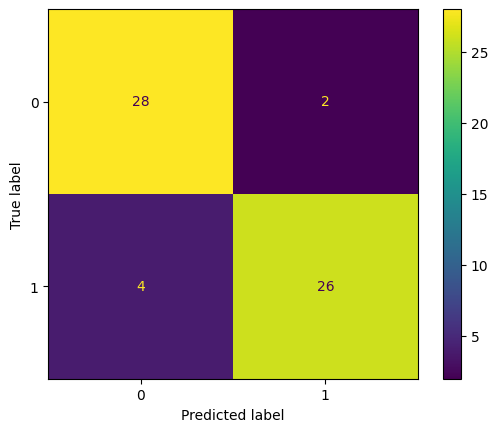

In [ ]:
# Display the confusion matrix.
ConfusionMatrixDisplay(cm).plot()

A simple metric to summarize the information of the confusion matrix is **accuracy**. It is the proportion of correct classifications for both classes, out of the total classifications made.

In python, we compute the accuracy using the function `accuracy_score()` from **scikit-learn**.


In [ ]:
# Calcular la exactitud.
accuracy = accuracy_score(Y_test, Y_pred_knn)

# Mostrar la exactitud.
print( round(accuracy, 2) )

0.9


## Determining the best number of nearest neighbours

We can determine the best value of *K* for the KNN algorithm using [$K$-fold cross-validation (CVV)]{style="color:orange;"}. To this end, we need to set up a grid search to try out different values of $K$ and measure its performance in terms of the $K$-fold CV estimate of accuracy.

We specify the grid search as follows:

In [ ]:
# Set the parameter to be changed and the range of values.
param_grid = {'n_neighbors': range(1, 31)}

# Create a KNeighborsClassifier object
knn_KFoldCV = KNeighborsClassifier()

# Set the grid search using K-fold CVV.
grid_search = GridSearchCV(knn_KFoldCV, param_grid, cv = 5,
                           scoring = 'accuracy')

# Run the search.
grid_search.fit(Xs_train, Y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': range(1, 31)}, scoring='accuracy')

We see the K-fold CV estimates of accuracy for each value of *K*:

In [ ]:
k_values = list(param_grid['n_neighbors'])
validation_accuracies = grid_search.cv_results_['mean_test_score']
validation_accuracies

array([0.97857143, 0.97857143, 0.97857143, 0.97857143, 0.98571429,
       0.97857143, 0.98571429, 0.97857143, 0.97857143, 0.97857143,
       0.97857143, 0.97857143, 0.97857143, 0.97857143, 0.97857143,
       0.97857143, 0.97857143, 0.97142857, 0.97857143, 0.97142857,
       0.97857143, 0.97857143, 0.97857143, 0.97857143, 0.97857143,
       0.97857143, 0.97857143, 0.97857143, 0.97857143, 0.97857143])

We can then visualize the accuracy for different values of $k$ using the following graph and code.

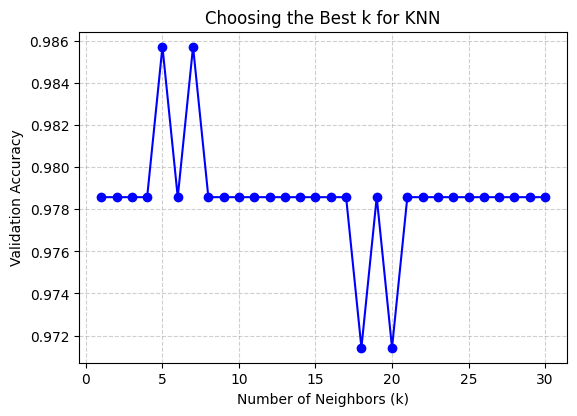

In [ ]:
# 2. Create the plot
plt.figure(figsize=(6.3, 4.3))
plt.plot(k_values, validation_accuracies, marker="o", linestyle="-", color='b')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Validation Accuracy")
plt.title("Choosing the Best k for KNN")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

We can easily determine the best value of *K* using the function `.best_params_['n_neighbors']`.

In [ ]:
best_k = grid_search.best_params_['n_neighbors']
best_k

5

Finally, we select the best number of nearest neighbors contained in the `best_k` object.

In [ ]:
KNN_final = KNeighborsClassifier(n_neighbors = best_k)
KNN_final.fit(Xs_train, Y_train)

KNeighborsClassifier()

This model has the following accuracy on the **test dataset**.

In [ ]:
Y_pred_KNNfinal = KNN_final.predict(Xs_test)
test_accuracy = accuracy_score(Y_test, Y_pred_KNNfinal)
print(test_accuracy)

0.9
